Importing dependencies

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import KFold, RandomizedSearchCV, GridSearchCV

Data Import and Profiling

In [65]:
exercise = pd.read_csv("exercise.csv")
calories = pd.read_csv("calories.csv")
#exercise.info()
#calories.info()
df = pd.merge(exercise, calories, on = "User_ID")
print(df.shape)

(15000, 9)


In [66]:
df['BMI'] = df['Weight'] / ((df['Height'] / 100) ** 2)
df['Gender_Encoded'] = df['Gender'].map({'male': 1, 'female': 0})

In [67]:
num_columns = ['Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp', 'Calories', 'BMI', 'Gender_Encoded']
non_num_rows = []
for col in num_columns:
    if col not in df.select_dtypes(include = 'number').columns:
        non_num_rows.append(col)
print(non_num_rows)
print(df['Gender'].unique())
print(df.isnull().sum())
print(df['User_ID'].duplicated().sum())
print(df[num_columns].describe(include = 'all'))

[]
<StringArray>
['male', 'female']
Length: 2, dtype: str
User_ID           0
Gender            0
Age               0
Height            0
Weight            0
Duration          0
Heart_Rate        0
Body_Temp         0
Calories          0
BMI               0
Gender_Encoded    0
dtype: int64
0
                Age        Height        Weight      Duration    Heart_Rate  \
count  15000.000000  15000.000000  15000.000000  15000.000000  15000.000000   
mean      42.789800    174.465133     74.966867     15.530600     95.518533   
std       16.980264     14.258114     15.035657      8.319203      9.583328   
min       20.000000    123.000000     36.000000      1.000000     67.000000   
25%       28.000000    164.000000     63.000000      8.000000     88.000000   
50%       39.000000    175.000000     74.000000     16.000000     96.000000   
75%       56.000000    185.000000     87.000000     23.000000    103.000000   
max       79.000000    222.000000    132.000000     30.000000    128.000000

Exploratory Data Analysis

Text(0.5, 1.0, 'Calories Distribution')

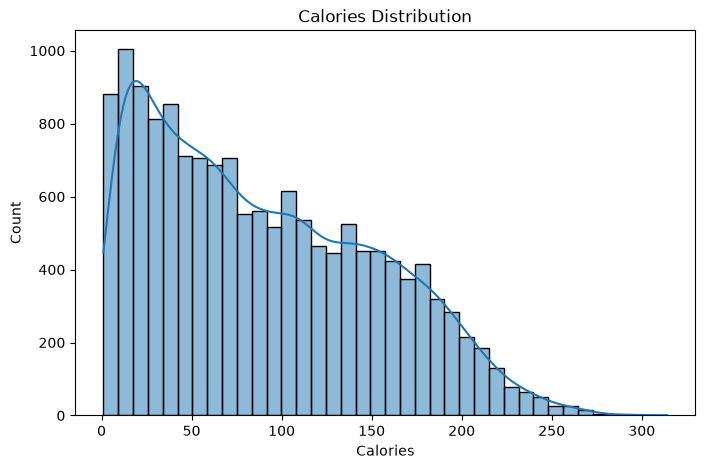

In [68]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Calories'], kde = True).set_title('Calories Distribution')

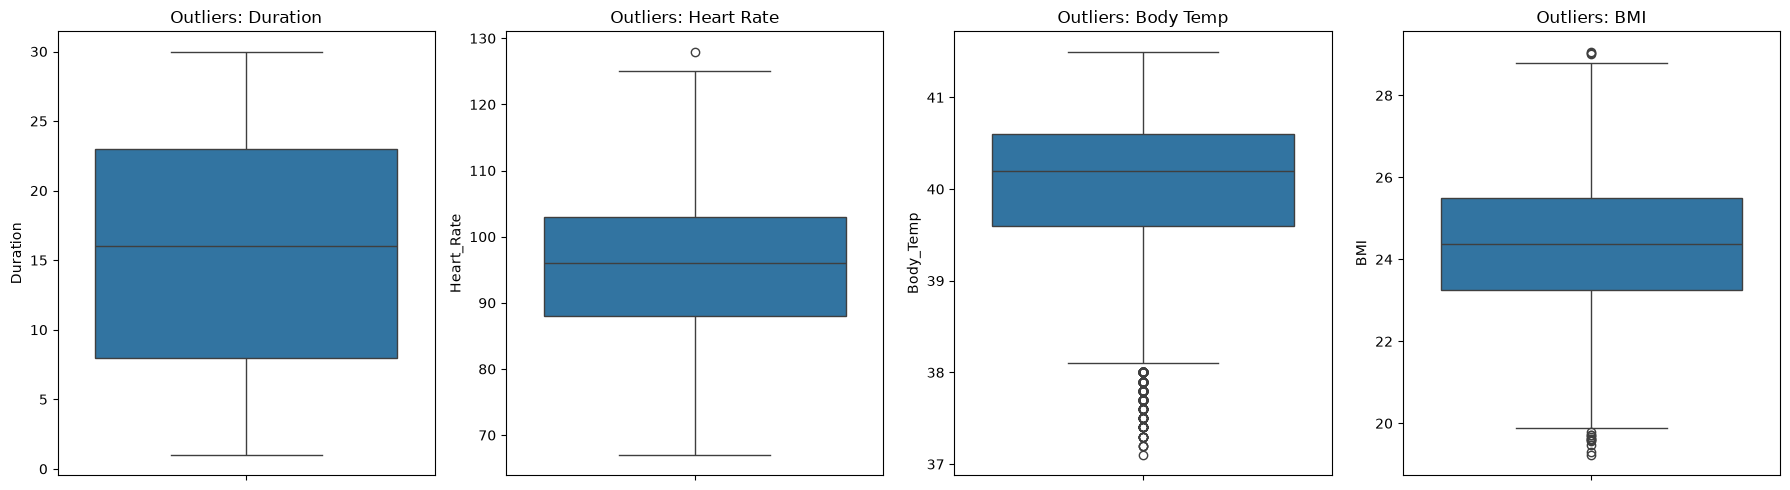

In [69]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
sns.boxplot(y=df['Duration'], ax=axes[0]).set_title('Outliers: Duration')
sns.boxplot(y=df['Heart_Rate'], ax=axes[1]).set_title('Outliers: Heart Rate')
sns.boxplot(y=df['Body_Temp'], ax=axes[2]).set_title('Outliers: Body Temp')
sns.boxplot(y=df['BMI'], ax=axes[3]).set_title('Outliers: BMI')
plt.tight_layout()
plt.show()

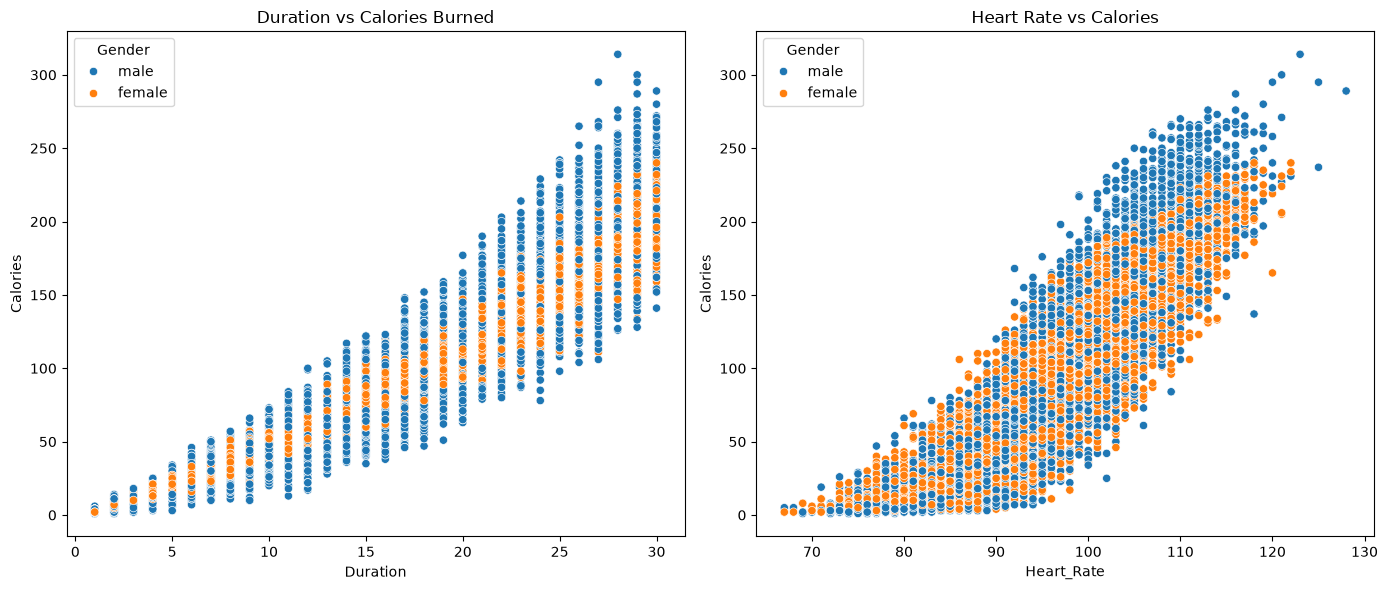

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.scatterplot(data=df, x='Duration', y='Calories', hue='Gender', ax=axes[0])
axes[0].set_title('Duration vs Calories Burned')
sns.scatterplot(data=df, x='Heart_Rate', y='Calories', hue='Gender', ax=axes[1])
axes[1].set_title('Heart Rate vs Calories')
plt.tight_layout()
plt.show()

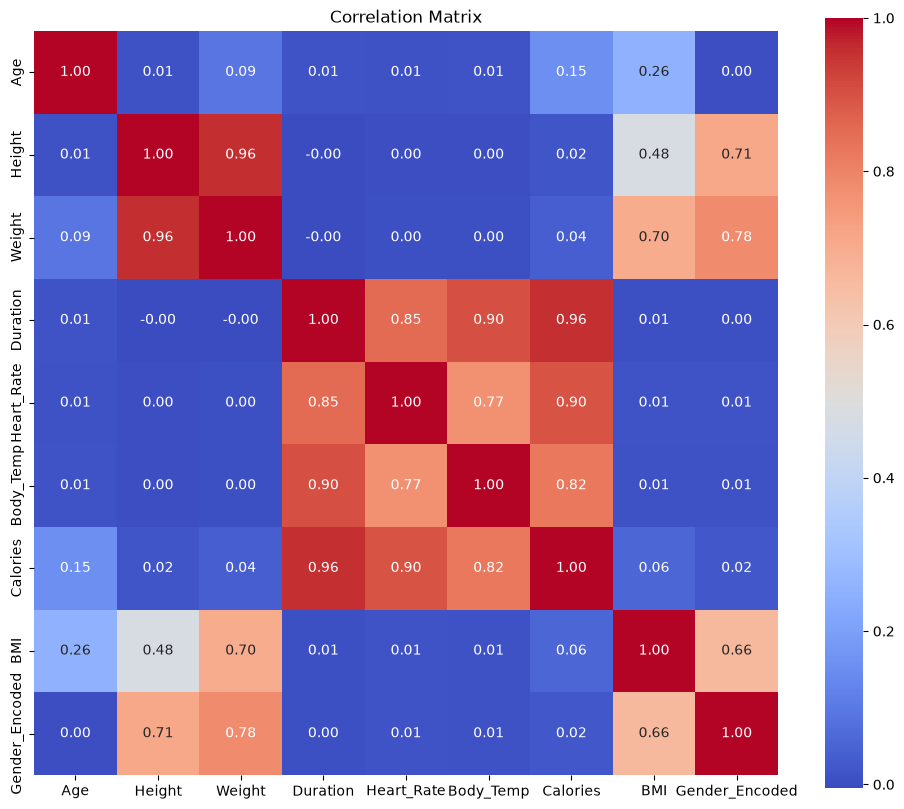

In [71]:
plt.figure(figsize=(12, 10))
sns.heatmap(df[num_columns].corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Matrix')
plt.show()

Data Preparation

In [72]:
calories_skew = df['Calories'].skew()
duration_skew = df['Duration'].skew()

print(f"Calories Skewness: {calories_skew:.2f}")
print(f"Duration Skewness: {duration_skew:.2f}")

def outliers(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    dataframe[column] = np.where(dataframe[column] < lower_bound, lower_bound, dataframe[column])
    dataframe[column] = np.where(dataframe[column] > upper_bound, upper_bound, dataframe[column])
    return dataframe

columns_with_outliers = ['Heart_Rate', 'Body_Temp', 'BMI']

for col in columns_with_outliers:
    df = outliers(df, col)

Calories Skewness: 0.51
Duration Skewness: 0.00


In [73]:
X = df.drop(columns=['Calories', 'User_ID', 'Gender'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")), 
            ("scaler", StandardScaler()),       
        ]), numeric_features),
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"X_train: {X_train.shape}")
print(f"X_train_processed shape: {X_train_processed.shape}")
print(f"X_test_processed shape: {X_test_processed.shape}")
print(f"Missing values remaining train: {np.isnan(X_train_processed).sum()}")
print(f"Missing values remaining test: {np.isnan(X_test_processed).sum()}")


X_train: (12000, 8)
X_train_processed shape: (12000, 8)
X_test_processed shape: (3000, 8)
Missing values remaining train: 0
Missing values remaining test: 0


Baseline Model Training and Evaluation

In [74]:
baseline_models = {
    'DecisionTree': DecisionTreeRegressor(max_depth=6, random_state=42),
    'KNN': KNeighborsRegressor(n_neighbors=15),
    'LinearRegression': LinearRegression(),
    'RandomForest': RandomForestRegressor(
        n_estimators=300, max_depth=8, random_state=42, n_jobs=-1
    ),
    'GradientBoosting': GradientBoostingRegressor(random_state=42),
}

fitted_models = {}
results = []

for name, model in baseline_models.items():
    model.fit(X_train_processed, y_train)
    fitted_models[name] = model
    
    y_pred = model.predict(X_test_processed)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({
        'Model': name,
        'R2 Score': r2,
        'RMSE': rmse,
        'MAE': mae
    })

    print(f'=== {name} ===')
    print(f'R2 Score : {r2:.4f}')
    print(f'RMSE     : {rmse:.4f}')
    print(f'MAE      : {mae:.4f}\n')

metrics_df = pd.DataFrame(results).sort_values(by='R2 Score', ascending=False)
print(metrics_df.to_string(index=False))

=== DecisionTree ===
R2 Score : 0.9731
RMSE     : 10.4229
MAE      : 7.4243

=== KNN ===
R2 Score : 0.9907
RMSE     : 6.1260
MAE      : 4.3891

=== LinearRegression ===
R2 Score : 0.9688
RMSE     : 11.2230
MAE      : 8.2097



=== RandomForest ===
R2 Score : 0.9943
RMSE     : 4.7938
MAE      : 3.3144

=== GradientBoosting ===
R2 Score : 0.9967
RMSE     : 3.6280
MAE      : 2.6184

           Model  R2 Score      RMSE      MAE
GradientBoosting  0.996739  3.627973 2.618353
    RandomForest  0.994306  4.793813 3.314371
             KNN  0.990701  6.125961 4.389067
    DecisionTree  0.973082 10.422895 7.424303
LinearRegression  0.968790 11.222994 8.209662


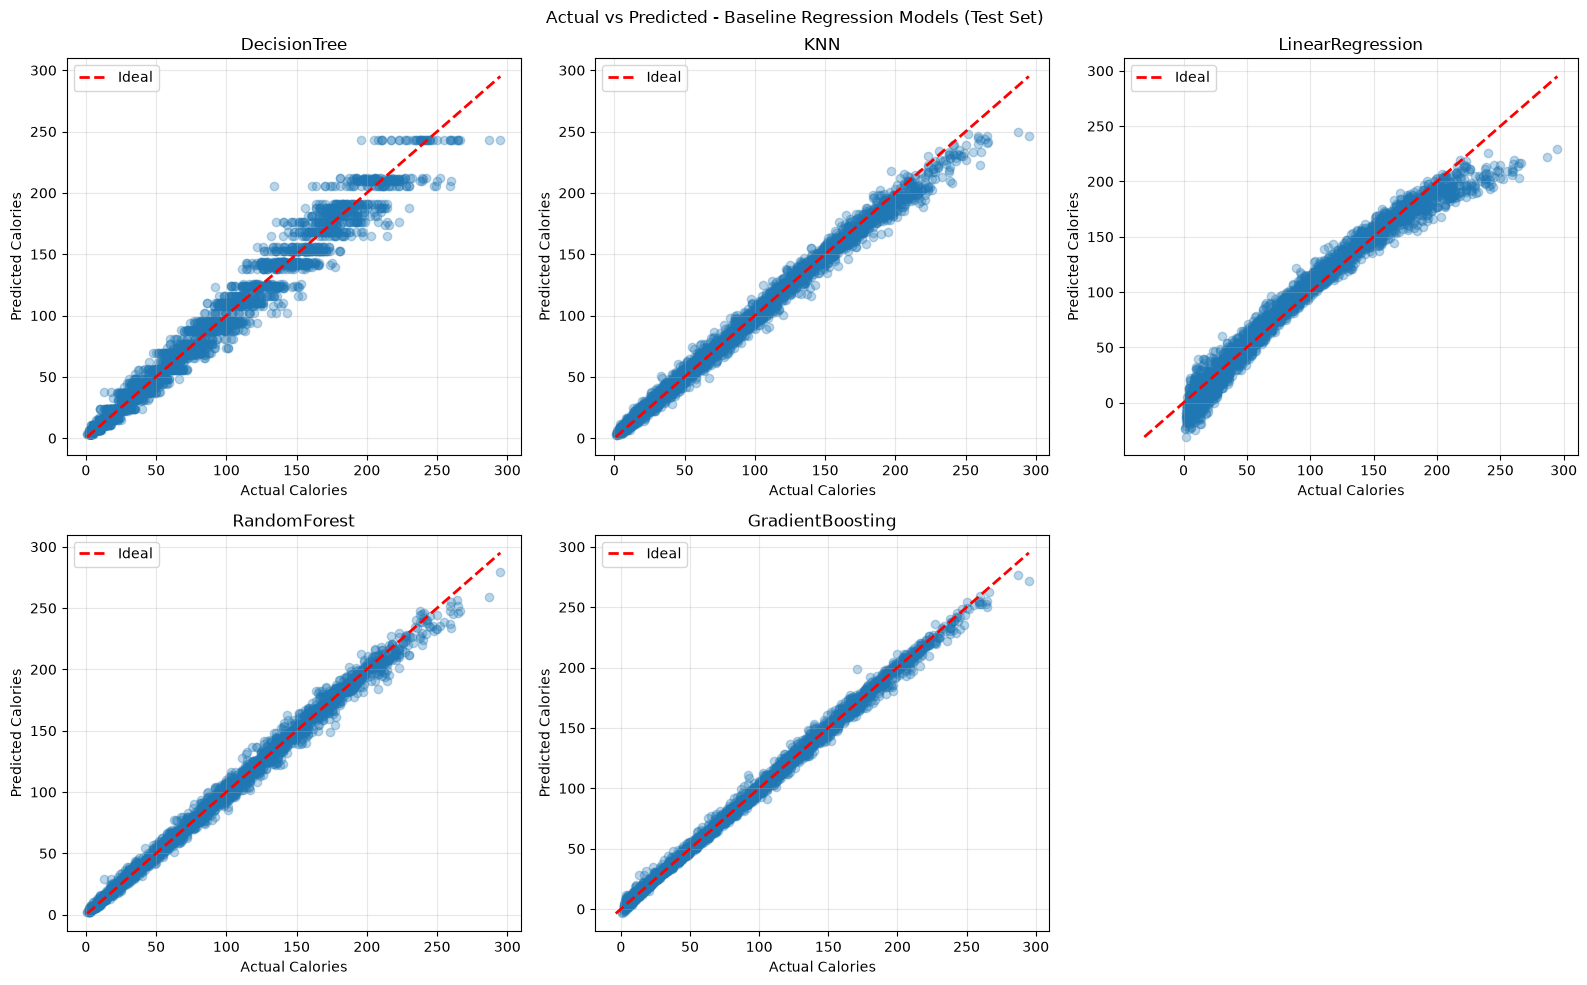

In [75]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for ax, (name, model) in zip(axes, fitted_models.items()):
    y_pred = model.predict(X_test_processed)
    
    ax.scatter(y_test, y_pred, alpha=0.3)
    
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Ideal')
    
    ax.set_title(f"{name}")
    ax.set_xlabel("Actual Calories")
    ax.set_ylabel("Predicted Calories")
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left')

for ax in axes[len(fitted_models):]:
    ax.axis("off")

plt.suptitle("Actual vs Predicted - Baseline Regression Models (Test Set)")
plt.tight_layout()
plt.show()

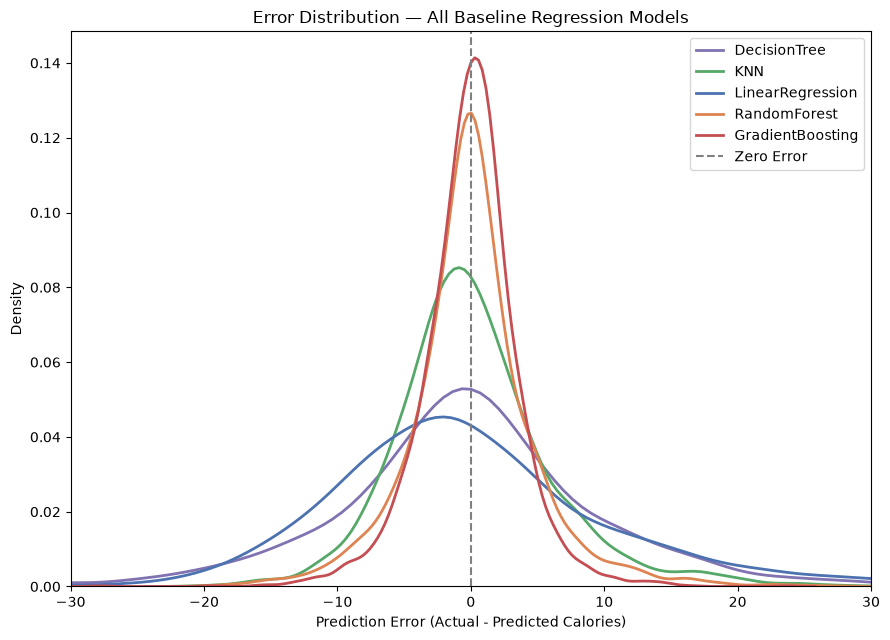

In [76]:
plt.figure(figsize=(9, 6.5))

model_colors = {
    "DecisionTree": "#8172B2",
    "KNN": "#55A868",
    "LinearRegression": "#4C72B0", # Заменили Logistic на Linear
    "RandomForest": "#DD8452",
    "GradientBoosting": "#C44E52",
}

for name, model in fitted_models.items():
    y_pred = model.predict(X_test_processed)
    residuals = y_test - y_pred  
    
    sns.kdeplot(residuals, color=model_colors.get(name, 'black'), label=f"{name}", linewidth=2)

plt.axvline(0, color="gray", linestyle="--", label="Zero Error")
plt.xlabel("Prediction Error (Actual - Predicted Calories)")
plt.ylabel("Density")
plt.title("Error Distribution — All Baseline Regression Models")
plt.xlim(-30, 30)
plt.legend()
plt.tight_layout()
plt.show()

Hyperparameter Tuning

In [ ]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

rf_param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [8, 12, None],
}
rf_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=rf_param_grid,
    n_iter=5,
    scoring="r2",
    cv=cv,
    random_state=42,
    n_jobs=-1,
)
rf_search.fit(X_train_processed, y_train)

gb_param_grid = {
    "n_estimators": [200, 400],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5],
}
gb_search = RandomizedSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_distributions=gb_param_grid,
    n_iter=5,
    scoring="r2",
    cv=cv,
    random_state=42,
    n_jobs=-1,
)
gb_search.fit(X_train_processed, y_train)

lin_reg = LinearRegression()
lin_reg.fit(X_train_processed, y_train)

tuned_models = {
    "LinearRegression": lin_reg,
    "RandomForest_tuned": rf_search.best_estimator_,
    "GradientBoosting_tuned": gb_search.best_estimator_,
}

print("Best Random Forest params:", rf_search.best_params_)
print("Best GradientBoosting params:", gb_search.best_params_)

=== Test-set evaluation: tuned models ===

--- LinearRegression ---
R2 Score : 0.9688
RMSE     : 11.2230
MAE      : 8.2097

--- RandomForest_tuned ---
R2 Score : 0.9982
RMSE     : 2.7185
MAE      : 1.7374

--- GradientBoosting_tuned ---
R2 Score : 0.9995
RMSE     : 1.4345
MAE      : 1.0157

=== Baseline vs Tuned: Test R2 Score Comparison ===
LinearRegression    : baseline=0.9688  tuned=0.9688
RandomForest        : baseline=0.9943  tuned=0.9982
GradientBoosting    : baseline=0.9967  tuned=0.9995


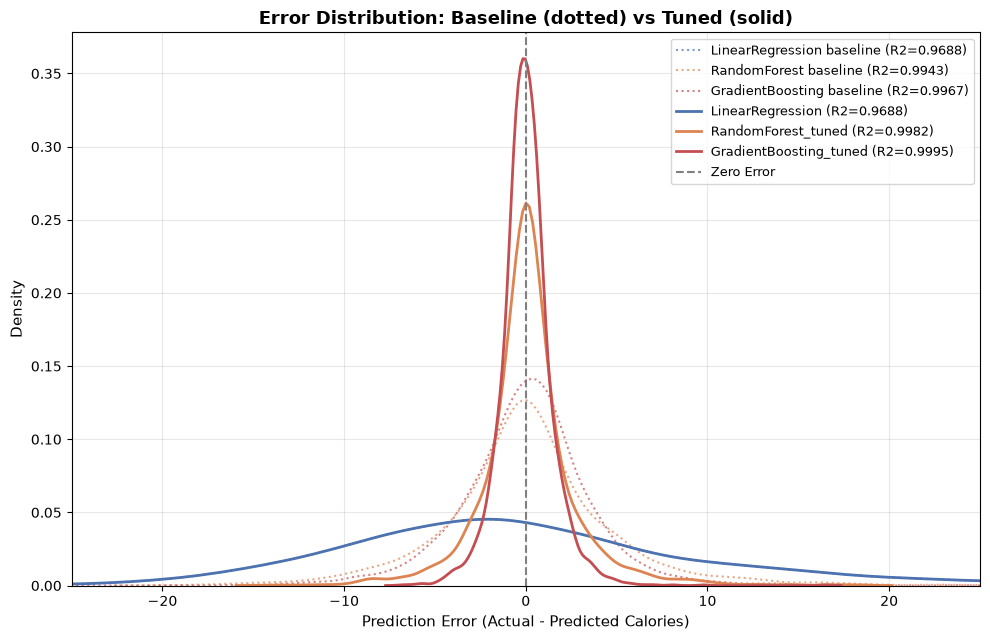

In [ ]:
baseline_test_metrics = {}
for name, model in fitted_models.items():
    y_pred = model.predict(X_test_processed)
    baseline_test_metrics[name] = {
        'R2': r2_score(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAE': mean_absolute_error(y_test, y_pred)
    }

print("=== Test-set evaluation: tuned models ===\n")
tuned_test_metrics = {}

for name, model in tuned_models.items():
    y_pred = model.predict(X_test_processed)
    
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    
    tuned_test_metrics[name] = {'R2': r2, 'RMSE': rmse, 'MAE': mae}
    
    print(f"--- {name} ---")
    print(f"R2 Score : {r2:.4f}")
    print(f"RMSE     : {rmse:.4f}")
    print(f"MAE      : {mae:.4f}\n")

print("=== Baseline vs Tuned: Test R2 Score Comparison ===")
print(f"LinearRegression    : baseline={baseline_test_metrics['LinearRegression']['R2']:.4f}  "
      f"tuned={tuned_test_metrics['LinearRegression']['R2']:.4f}")
print(f"RandomForest        : baseline={baseline_test_metrics['RandomForest']['R2']:.4f}  "
      f"tuned={tuned_test_metrics['RandomForest_tuned']['R2']:.4f}")
print(f"GradientBoosting    : baseline={baseline_test_metrics['GradientBoosting']['R2']:.4f}  "
      f"tuned={tuned_test_metrics['GradientBoosting_tuned']['R2']:.4f}")

plt.figure(figsize=(10, 6.5))

model_colors = {
    "LinearRegression": "#4C72B0", 
    "RandomForest": "#DD8452", 
    "GradientBoosting": "#C44E52"
}

for base_name in model_colors:
    base_model = fitted_models[base_name]
    y_pred_base = base_model.predict(X_test_processed)
    residuals_base = y_test - y_pred_base
    r2_base = baseline_test_metrics[base_name]['R2']
    
    sns.kdeplot(residuals_base, color=model_colors[base_name], linestyle=":", linewidth=1.5, alpha=0.7,
                label=f"{base_name} baseline (R2={r2_base:.4f})")

for tuned_name, tuned_model in tuned_models.items():
    base_name = tuned_name.replace("_tuned", "")
    y_pred_tuned = tuned_model.predict(X_test_processed)
    residuals_tuned = y_test - y_pred_tuned
    r2_tuned = tuned_test_metrics[tuned_name]['R2']
    
    sns.kdeplot(residuals_tuned, color=model_colors[base_name], linestyle="-", linewidth=2,
                label=f"{tuned_name} (R2={r2_tuned:.4f})")

plt.axvline(0, color="gray", linestyle="--", label="Zero Error")
plt.xlabel("Prediction Error (Actual - Predicted Calories)", fontsize=11)
plt.ylabel("Density", fontsize=11)
plt.title("Error Distribution: Baseline (dotted) vs Tuned (solid)", fontsize=13, fontweight='bold')
plt.xlim(-25, 25)
plt.legend(fontsize=9, loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()